In [3]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
import os
print(os.getcwd())

C:\Users\Rayen


(np.float64(-0.5), np.float64(235.5), np.float64(314.5), np.float64(-0.5))

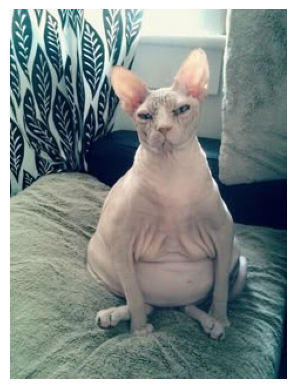

In [108]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("C:/Users/Rayen/Documents/project cat-breed/3omda.jpg")
plt.imshow(img)
plt.axis("off")

In [110]:
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

img_tensor = transform(img)

In [111]:
import torchvision.models as models

model = models.resnet18(pretrained=True)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [112]:
img_tensor = img_tensor.unsqueeze(0)  # add batch dimension

output = model(img_tensor)
print(output.shape)

torch.Size([1, 1000])


In [113]:
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms

class CatDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform
        
        self.image_files = [
            f for f in os.listdir(folder_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ]
        
        self.breeds = sorted(list(set([
            "_".join(img.replace(".jpg", "").split("_")[:-1]) 
            for img in self.image_files
        ])))
        
        self.breed_to_idx = {breed: i for i, breed in enumerate(self.breeds)}

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_name = self.image_files[idx]
        img_path = os.path.join(self.folder_path, img_name)
        
        image = Image.open(img_path).convert("RGB")
        
        if self.transform:
            image = self.transform(image)
        
        breed = "_".join(img_name.replace(".jpg", "").split("_")[:-1])
        label = self.breed_to_idx[breed]
        
        return image, label

In [114]:
dataset = CatDataset("C:/Users/Rayen/Documents/project cat-breed/data/images", transform=transform)

In [115]:
img, label = dataset[0]

print(img.shape)   # should be (3, 224, 224)
print(label)       # integer
print(dataset.breed_to_idx)

torch.Size([3, 224, 224])
0
{'Abyssinian': 0, 'Bengal': 1, 'Birman': 2, 'Bombay': 3, 'British_Shorthair': 4, 'Egyptian_Mau': 5, 'Maine_Coon': 6, 'Persian': 7, 'Ragdoll': 8, 'Russian_Blue': 9, 'Siamese': 10, 'Sphynx': 11, 'american_bulldog': 12, 'american_pit_bull_terrier': 13, 'basset_hound': 14, 'beagle': 15, 'boxer': 16, 'chihuahua': 17, 'english_cocker_spaniel': 18, 'english_setter': 19, 'german_shorthaired': 20, 'great_pyrenees': 21, 'havanese': 22, 'japanese_chin': 23, 'keeshond': 24, 'leonberger': 25, 'miniature_pinscher': 26, 'newfoundland': 27, 'pomeranian': 28, 'pug': 29, 'saint_bernard': 30, 'samoyed': 31, 'scottish_terrier': 32, 'shiba_inu': 33, 'staffordshire_bull_terrier': 34, 'wheaten_terrier': 35, 'yorkshire_terrier': 36}


In [116]:
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

In [117]:
for images, labels in dataloader:
    print(images.shape)  # (32, 3, 224, 224)
    print(labels.shape)  # (32,)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [118]:
import torch.nn as nn

NUM_CLASSES = len(dataset.breeds)  # 35 breeds (cats + dogs)
print(f"Number of classes: {NUM_CLASSES}")

model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
print(model.fc)  # should show: Linear(in_features=512, out_features=35)

Number of classes: 37
Linear(in_features=512, out_features=37, bias=True)


In [119]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")  # should print: Using device: cuda

model = model.to(device)

Using device: cuda


In [121]:
import torch.optim as optim

# ── define loss and optimizer (add this BEFORE the loop) ──
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ── switch model to training mode ──
model.train()

# ── training loop ──
for epoch in range(10):
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in dataloader:
        # move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # 1. clear old gradients FIRST
        optimizer.zero_grad()

        # 2. forward pass — get predictions
        outputs = model(images)

        # 3. calculate loss
        loss = criterion(outputs, labels)

        # 4. backpropagation — calculate gradients
        loss.backward()

        # 5. update weights
        optimizer.step()

        # track stats
        total_loss += loss.item()
        predicted = outputs.argmax(dim=1)   # index of highest score
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total
    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch+1}/10 — Loss: {avg_loss:.4f} — Accuracy: {accuracy:.2f}%")

Epoch 1/10 — Loss: 0.3350 — Accuracy: 89.53%
Epoch 2/10 — Loss: 0.2197 — Accuracy: 93.23%
Epoch 3/10 — Loss: 0.1657 — Accuracy: 95.05%
Epoch 4/10 — Loss: 0.1842 — Accuracy: 93.68%
Epoch 5/10 — Loss: 0.1145 — Accuracy: 96.27%
Epoch 6/10 — Loss: 0.1738 — Accuracy: 94.55%
Epoch 7/10 — Loss: 0.1186 — Accuracy: 96.31%
Epoch 8/10 — Loss: 0.0952 — Accuracy: 96.96%
Epoch 9/10 — Loss: 0.0937 — Accuracy: 96.98%
Epoch 10/10 — Loss: 0.0848 — Accuracy: 97.28%


In [139]:
from PIL import Image
import torchvision.transforms as transforms
import torch

def predict(image_path):
    # same transform as training
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        )
    ])
    
    # load and transform the image
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0)  # add batch dimension → (1, 3, 224, 224)
    
    # move to GPU
    image = image.to(device)
    
    # predict
    model.eval()  # switch to evaluation mode
    with torch.no_grad():  # no need to calculate gradients
        outputs = model(image)
        probabilities = torch.softmax(outputs, dim=1)[0]  # convert scores to percentages
        top3 = probabilities.topk(3)  # get top 3 predictions
    
    # print results
    print("=" * 35)
    print(f"  Top 3 predictions:")
    print("=" * 35)
    for i in range(3):
        idx = top3.indices[i].item()
        prob = top3.values[i].item() * 100
        breed = dataset.breeds[idx]
        print(f"  {i+1}. {breed:<25} {prob:.1f}%")
    print("=" * 35)

# ── TEST IT ──
predict("C:/Users/Rayen/Documents/project cat-breed/3omda.jpg")

  Top 3 predictions:
  1. Sphynx                    94.6%
  2. chihuahua                 2.4%
  3. Russian_Blue              0.9%


In [141]:
torch.save(model.state_dict(), "C:/Users/Rayen/Documents/project cat-breed/cat_breed_model.pth")
print("Model saved!")

Model saved!


In [142]:
import json

with open("C:/Users/Rayen/Documents/project cat-breed/breeds.json", "w") as f:
    json.dump(dataset.breeds, f)

print("Breeds saved!")
print(dataset.breeds)  # so you can see what was saved

Breeds saved!
['Abyssinian', 'Bengal', 'Birman', 'Bombay', 'British_Shorthair', 'Egyptian_Mau', 'Maine_Coon', 'Persian', 'Ragdoll', 'Russian_Blue', 'Siamese', 'Sphynx', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'boxer', 'chihuahua', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'miniature_pinscher', 'newfoundland', 'pomeranian', 'pug', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
